# Load Config

## Configuration File as YAML 

```
session:
  IpAddress: '10.36.94.225'
  RestPort: null
  UserName: seunyang
  Password: seunyang
  SessionName: null
  SessionId: null
  ApiKey: null
  ClearConfig: True
  LogLevel: info
  LogFilename: restpy.log

portMap:
  - IpAddress: 10.36.88.110
    CardId: 1
    PortId: 3
    Name: 'Port_1'
    Media: fiber
  - IpAddress: 10.36.88.110
    CardId: 1
    PortId: 4
    Name: 'Port_2'
    Media: fiber
```

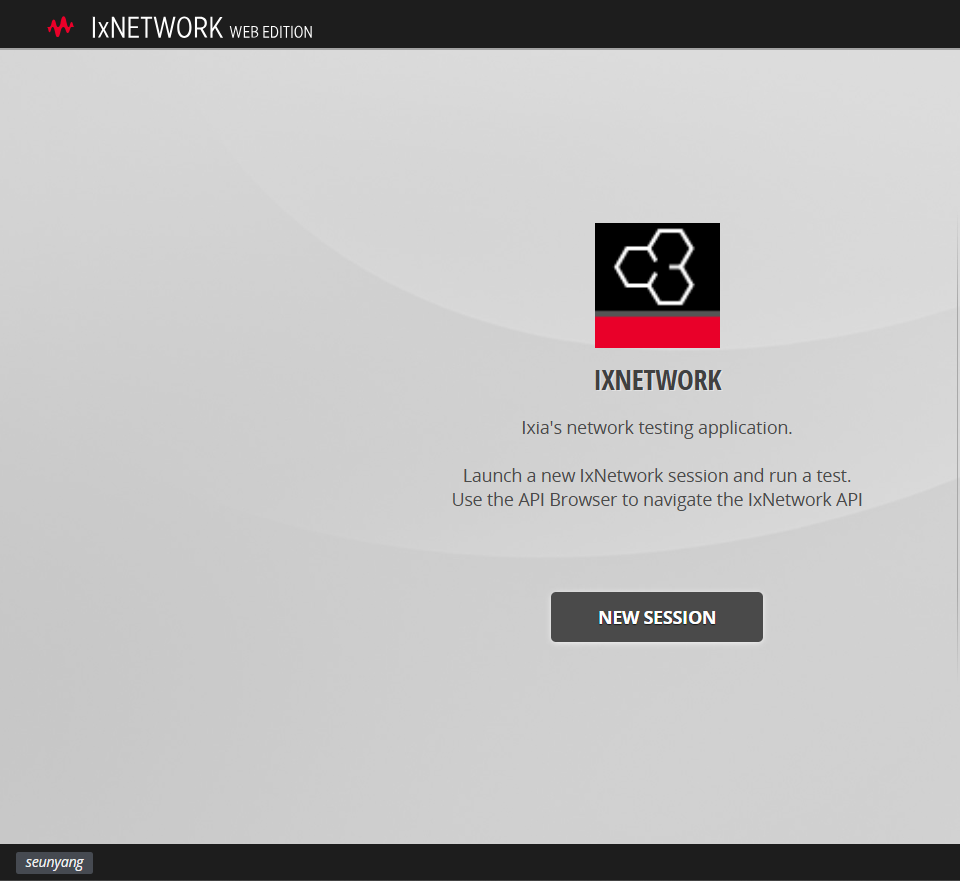

In [33]:
import yaml

# Import the RestPy module
from ixnetwork_restpy import SessionAssistant

# For linux and connection_manager only. Set to True to leave the session alive for debugging.
debugMode = False

def load_config(config_file_path):
    with open(config_file_path, 'r') as file:
        try:
            # Use safe_load to safely parse the YAML content
            config_data = yaml.safe_load(file)
            return config_data
        except yaml.YAMLError as exc:
            print(exc)
            return None
config=load_config('ixnetwork_config.yaml')
config 

{'session': {'IpAddress': '10.36.94.225',
  'RestPort': None,
  'UserName': 'seunyang',
  'Password': 'seunyang',
  'SessionName': None,
  'SessionId': None,
  'ApiKey': None,
  'ClearConfig': True,
  'LogLevel': 'info',
  'LogFilename': 'restpy.log'},
 'portMap': [{'IpAddress': '10.36.88.110',
   'CardId': 1,
   'PortId': 3,
   'Name': 'Port_1',
   'Media': 'fiber'},
  {'IpAddress': '10.36.88.110',
   'CardId': 1,
   'PortId': 4,
   'Name': 'Port_2',
   'Media': 'fiber'}]}

In [21]:
config['session']

{'IpAddress': '10.36.94.225',
 'RestPort': None,
 'UserName': 'seunyang',
 'Password': 'seunyang',
 'SessionName': None,
 'SessionId': None,
 'ApiKey': None,
 'ClearConfig': True,
 'LogLevel': 'info',
 'LogFilename': 'restpy.log'}

In [22]:
config['portMap']

[{'IpAddress': '10.36.88.110',
  'CardId': 1,
  'PortId': 3,
  'Name': 'Port_1',
  'Media': 'fiber'},
 {'IpAddress': '10.36.88.110',
  'CardId': 1,
  'PortId': 4,
  'Name': 'Port_2',
  'Media': 'fiber'}]

In [23]:
print(config['portMap'][0])
print(config['portMap'][1])

{'IpAddress': '10.36.88.110', 'CardId': 1, 'PortId': 3, 'Name': 'Port_1', 'Media': 'fiber'}
{'IpAddress': '10.36.88.110', 'CardId': 1, 'PortId': 4, 'Name': 'Port_2', 'Media': 'fiber'}


# Create a session

In [29]:
session = SessionAssistant(
    IpAddress=config['session']['IpAddress'], 
    RestPort=config['session']['RestPort'], 
    UserName=config['session']['UserName'], 
    Password=config['session']['Password'],
    SessionName=config['session']['SessionName'], 
    SessionId=config['session']['SessionId'],
    ApiKey=config['session']['ApiKey'],
    ClearConfig=config['session']['ClearConfig'], 
    LogLevel=config['session']['LogLevel'], 
    LogFilename=config['session']['LogFilename'])

ixNetwork = session.Ixnetwork

2026-03-25 17:58:42 [ixnetwork_restpy.connection tid:133912356457536] [WARNING] Verification of certificates is disabled
2026-03-25 17:58:42 [ixnetwork_restpy.connection tid:133912356457536] [INFO] Determining the platform and rest_port using the 10.36.94.225 address...
2026-03-25 17:58:42 [ixnetwork_restpy.connection tid:133912356457536] [WARNING] Unable to connect to http://10.36.94.225:443.
2026-03-25 17:58:42 [ixnetwork_restpy.connection tid:133912356457536] [INFO] Connection established to `https://10.36.94.225:443 on linux`
2026-03-25 17:59:16 [ixnetwork_restpy.connection tid:133912356457536] [INFO] Using IxNetwork api server version 11.10.2508.10
2026-03-25 17:59:16 [ixnetwork_restpy.connection tid:133912356457536] [INFO] User info IxNetwork/ixnetworkweb/seunyang-80-3318428


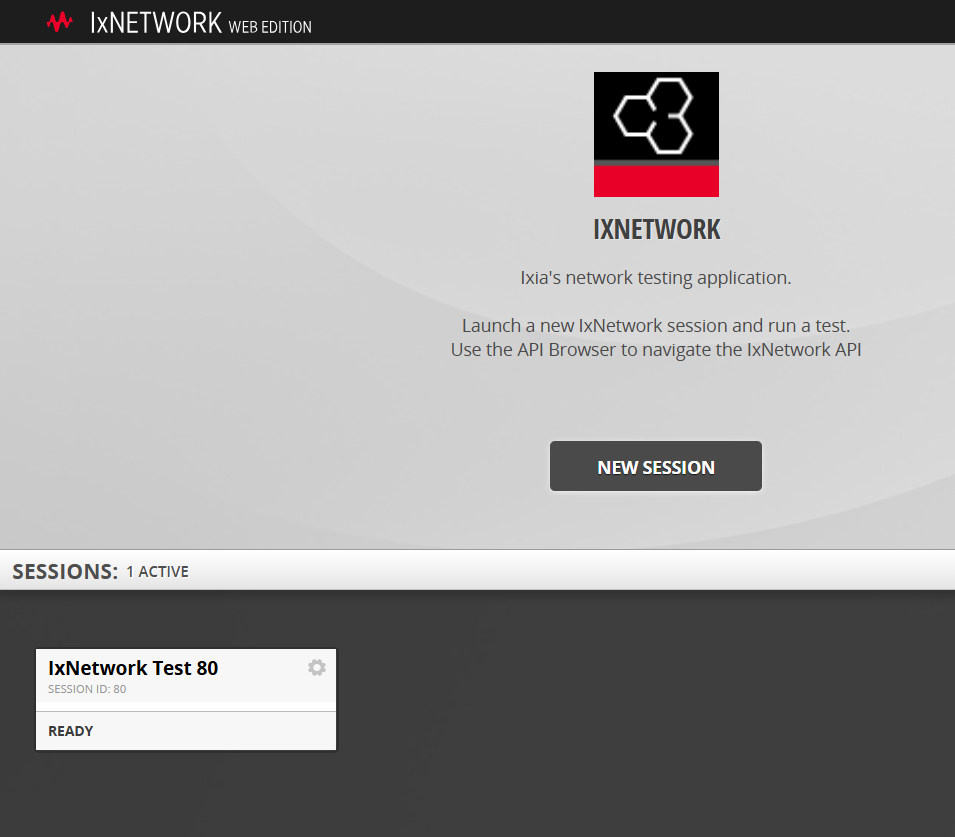

# Configure PortMap

In [30]:
ixNetwork.info('Assign ports')
portMap = session.PortMapAssistant()
vport1 = portMap.Map(
    IpAddress=config['portMap'][0]['IpAddress'],
    CardId=config['portMap'][0]['CardId'],
    PortId=config['portMap'][0]['PortId'],
    Name=config['portMap'][0]['Name']
)
vport2 = portMap.Map(
    IpAddress=config['portMap'][1]['IpAddress'],
    CardId=config['portMap'][1]['CardId'],
    PortId=config['portMap'][1]['PortId'],
    Name=config['portMap'][1]['Name']
)
vport1.L1Config.Ethernet.update(Media = config['portMap'][0]['Media'])
vport2.L1Config.Ethernet.update(Media = config['portMap'][0]['Media'])

portMap.Connect(ForceOwnership=True)

2026-03-25 18:00:22 [ixnetwork_restpy.connection tid:133912356457536] [INFO] Assign ports
2026-03-25 18:00:28 [ixnetwork_restpy.connection tid:133912356457536] [INFO] Adding test port hosts [10.36.88.110]...
2026-03-25 18:00:34 [ixnetwork_restpy.connection tid:133912356457536] [INFO] PortMapAssistant._add_hosts duration: 6.095998525619507secs
2026-03-25 18:00:34 [ixnetwork_restpy.connection tid:133912356457536] [INFO] Connecting virtual ports to test ports using location
2026-03-25 18:00:53 [ixnetwork_restpy.connection tid:133912356457536] [INFO] PortMapAssistant._connect_ports duration: 18.01521110534668secs
2026-03-25 18:00:53 [ixnetwork_restpy.connection tid:133912356457536] [INFO] Checking virtual port link states
2026-03-25 18:01:04 [ixnetwork_restpy.connection tid:133912356457536] [INFO] PortMapAssistant._check_link_state duration: 11.517366647720337secs


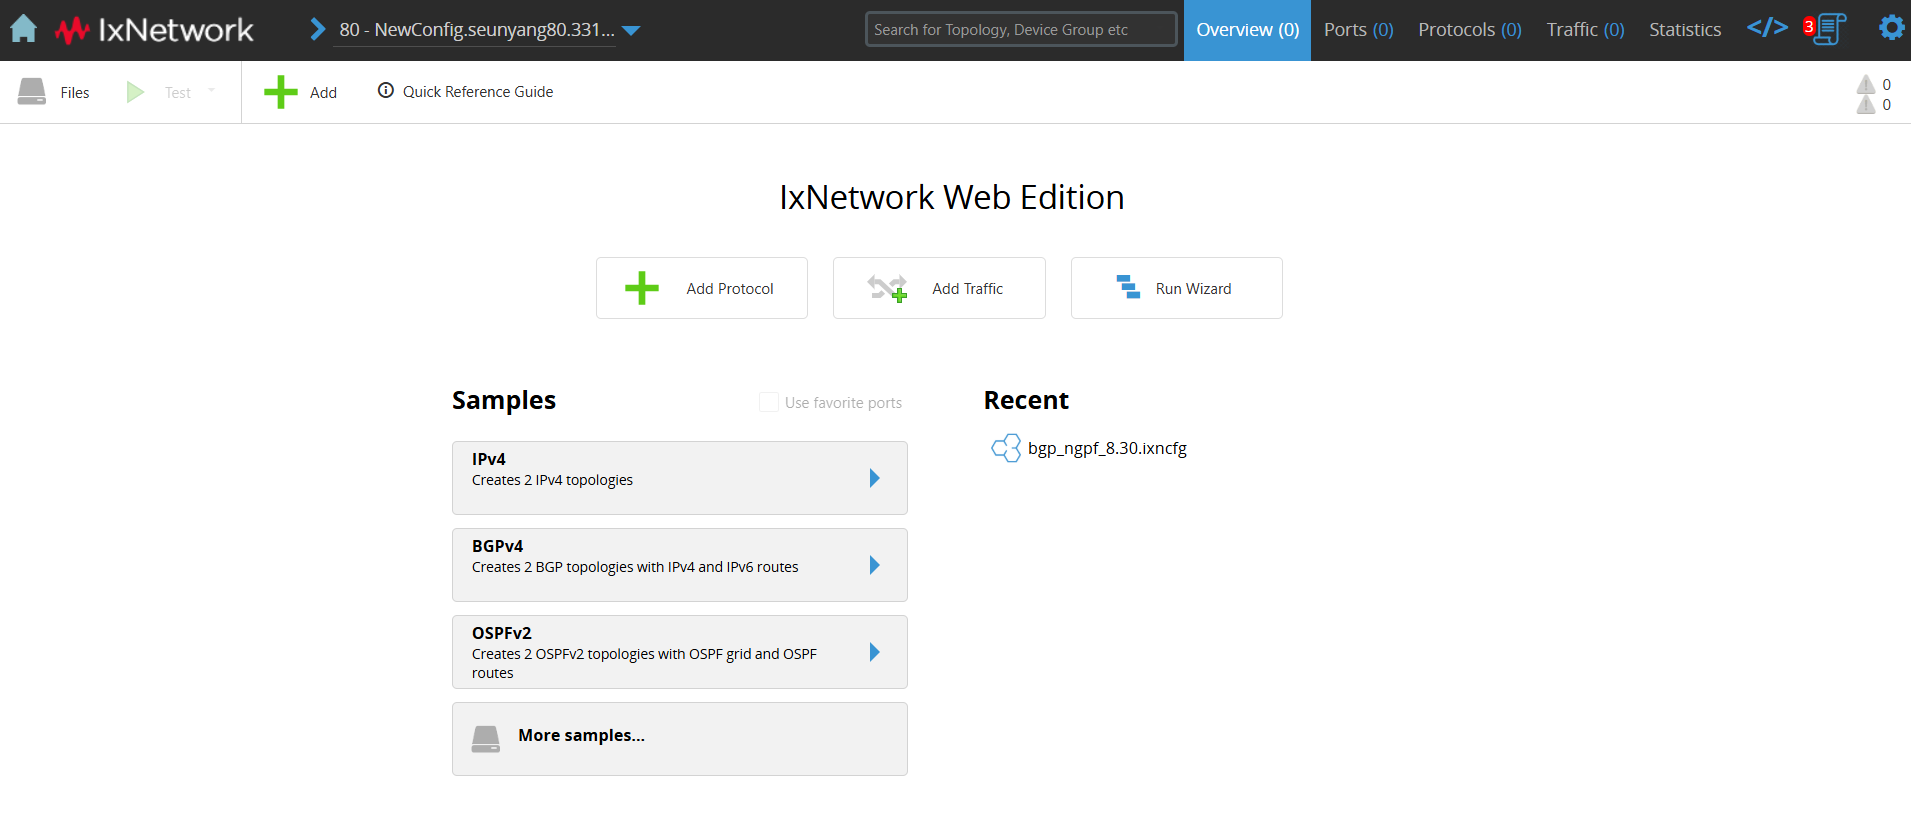

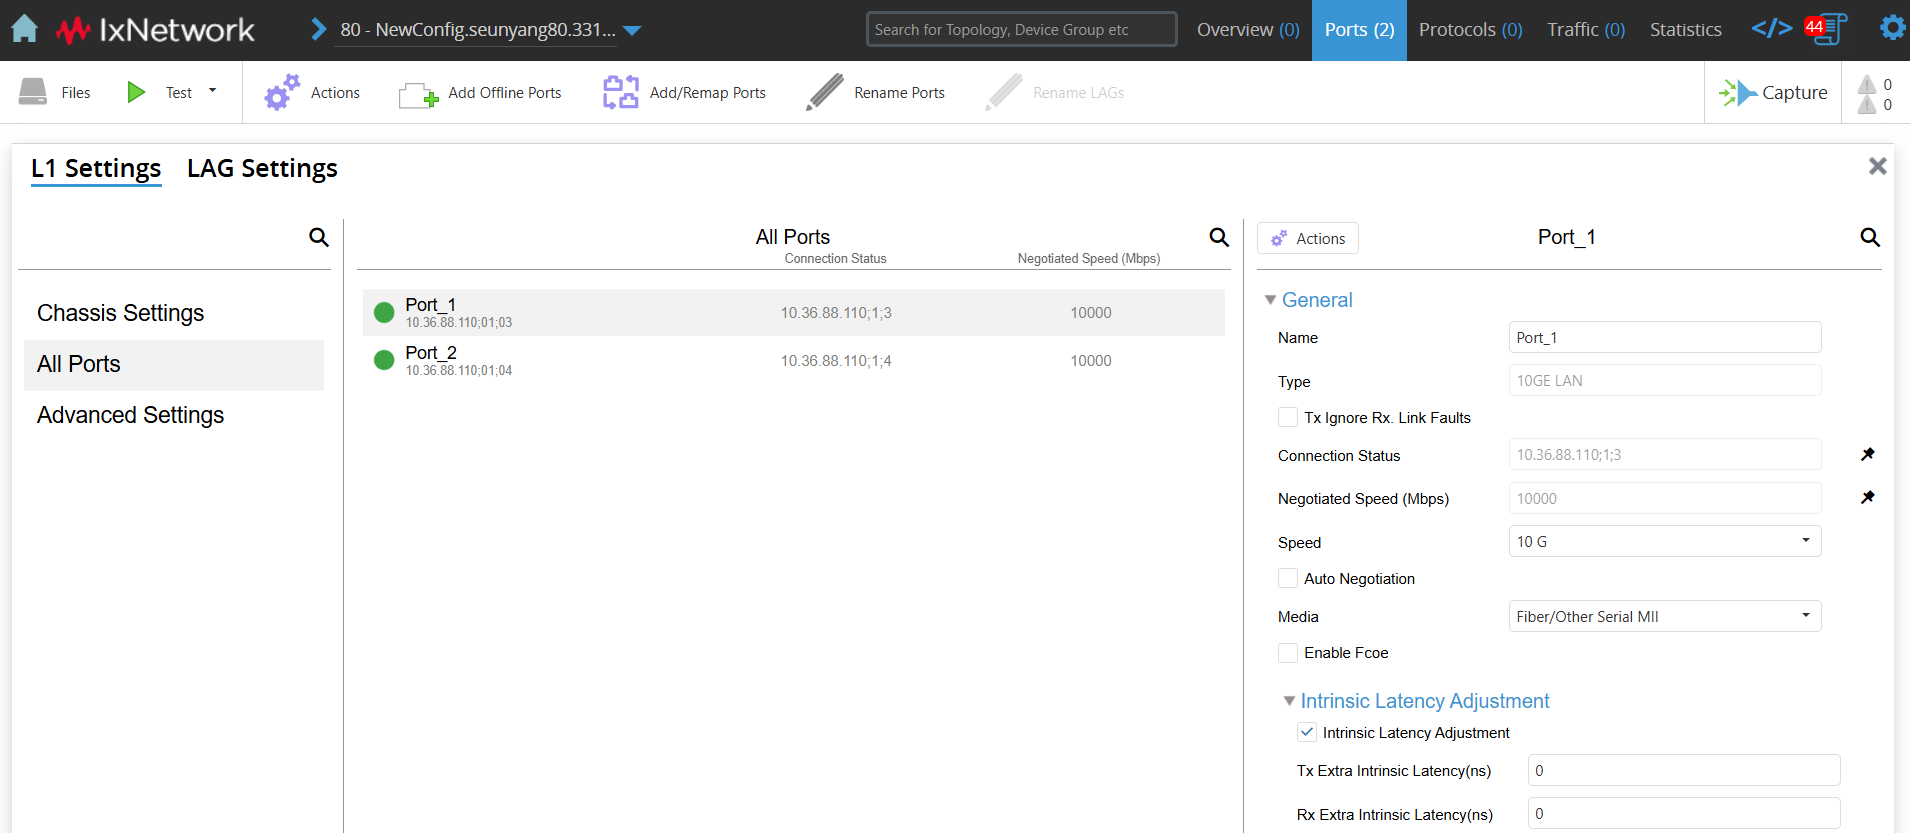

# Test Body

In [31]:
ixNetwork.info('Creating Topology Group 1')
topology1 = ixNetwork.Topology.add(Name='Topo1', Ports=vport1)

ixNetwork.info('Creating Device Group 1')
deviceGroup1 = topology1.DeviceGroup.add(Name='DG1', Multiplier='1')

ixNetwork.info('Creating Ethernet stack 1')
ethernet1 = deviceGroup1.Ethernet.add(Name='Eth1')
ethernet1.Mac.Increment(start_value='00:01:01:01:00:01', step_value='00:00:00:00:00:01')

ixNetwork.info('Enabling Vlan on Topology 1')
ethernet1.EnableVlans.Single(True)

ixNetwork.info('Configuring vlanID')
vlanObj = ethernet1.Vlan.find()[0].VlanId.Increment(start_value=103, step_value=0)

ixNetwork.info('Configuring IPv4')
ipv4 = ethernet1.Ipv4.add(Name='Ipv4')
ipv4.Address.Increment(start_value='1.1.1.1', step_value='0.0.0.1')
ipv4.GatewayIp.Increment(start_value='1.1.1.2', step_value='0.0.0.0')

ixNetwork.info('Configuring BgpIpv4Peer 1')
bgp1 = ipv4.BgpIpv4Peer.add(Name='Bgp1')
bgp1.DutIp.Increment(start_value='1.1.1.2', step_value='0.0.0.0')
bgp1.Type.Single('internal')
bgp1.LocalAs2Bytes.Increment(start_value=101, step_value=0)

ixNetwork.info('Configuring Network Group 1')
networkGroup1 = deviceGroup1.NetworkGroup.add(Name='BGP-Routes1', Multiplier='100')
ipv4PrefixPool = networkGroup1.Ipv4PrefixPools.add(NumberOfAddresses='1')
ipv4PrefixPool.NetworkAddress.Increment(start_value='10.10.0.1', step_value='0.0.0.1')
ipv4PrefixPool.PrefixLength.Single(32)

ixNetwork.info('Creating Topology Group 2')
topology2 = ixNetwork.Topology.add(Name='Topo2', Ports=vport2)

ixNetwork.info('Creating Device Group 2')
deviceGroup2 = topology2.DeviceGroup.add(Name='DG2', Multiplier='1')

ixNetwork.info('Creating Ethernet 2')
ethernet2 = deviceGroup2.Ethernet.add(Name='Eth2')
ethernet2.Mac.Increment(start_value='00:01:01:02:00:01', step_value='00:00:00:00:00:01')

ixNetwork.info('Enabling Vlan on Topology 2')
ethernet2.EnableVlans.Single(True)

ixNetwork.info('Configuring vlanID')
vlanObj = ethernet2.Vlan.find()[0].VlanId.Increment(start_value=103, step_value=0)

ixNetwork.info('Configuring IPv4 2')
ipv4 = ethernet2.Ipv4.add(Name='Ipv4-2')
ipv4.Address.Increment(start_value='1.1.1.2', step_value='0.0.0.1')
ipv4.GatewayIp.Increment(start_value='1.1.1.1', step_value='0.0.0.0')

ixNetwork.info('Configuring BgpIpv4Peer 2')
bgp2 = ipv4.BgpIpv4Peer.add(Name='Bgp2')
bgp2.DutIp.Increment(start_value='1.1.1.1', step_value='0.0.0.0')
bgp2.Type.Single('internal')
bgp2.LocalAs2Bytes.Increment(start_value=101, step_value=0)

ixNetwork.info('Configuring Network Group 2')
networkGroup2 = deviceGroup2.NetworkGroup.add(Name='BGP-Routes2', Multiplier='100')
ipv4PrefixPool = networkGroup2.Ipv4PrefixPools.add(NumberOfAddresses='1')
ipv4PrefixPool.NetworkAddress.Increment(start_value='20.20.0.1', step_value='0.0.0.1')
ipv4PrefixPool.PrefixLength.Single(32)

ixNetwork.info('Starting NGPF protocols')
ixNetwork.StartAllProtocols(Arg1='sync')

ixNetwork.info('Verify protocol sessions\n')
protocolSummary = session.StatViewAssistant('Protocols Summary')
protocolSummary.CheckCondition('Sessions Not Started', protocolSummary.EQUAL, 0)
protocolSummary.CheckCondition('Sessions Down', protocolSummary.EQUAL, 0)

ixNetwork.info('Create Traffic Item')
trafficItem = ixNetwork.Traffic.TrafficItem.add(Name='BGP Traffic', BiDirectional=False, TrafficType='ipv4')

ixNetwork.info('Add source/dest endpoints')
trafficItem.EndpointSet.add(Sources=topology1, Destinations=topology2)

# Note: A Traffic Item could have multiple EndpointSets (Flow groups).
#       Therefore, ConfigElement is a list.
ixNetwork.info('Configuring config elements')
configElement = trafficItem.ConfigElement.find()[0]
configElement.FrameRate.update(Type='percentLineRate', Rate=50)
configElement.TransmissionControl.update(Type='fixedFrameCount', FrameCount=10000)
configElement.FrameRateDistribution.PortDistribution = 'splitRateEvenly'
configElement.FrameSize.FixedSize = 128
trafficItem.Tracking.find()[0].TrackBy = ['flowGroup0']

trafficItem.Generate()

ixNetwork.info('Apply config')
ixNetwork.Traffic.Apply()

ixNetwork.info('Starting traffic')
ixNetwork.Traffic.StartStatelessTrafficBlocking()

flowStatistics = session.StatViewAssistant('Flow Statistics')

ixNetwork.info('{}\n'.format(flowStatistics))

for rowNumber,flowStat in enumerate(flowStatistics.Rows):
    ixNetwork.info('\n\nSTATS: {}\n\n'.format(flowStat))
    ixNetwork.info('\nRow:{}  TxPort:{}  RxPort:{}  TxFrames:{}  RxFrames:{}\n'.format(
        rowNumber, flowStat['Tx Port'], flowStat['Rx Port'],
        flowStat['Tx Frames'], flowStat['Rx Frames']))

2026-03-25 18:01:51 [ixnetwork_restpy.connection tid:133912356457536] [INFO] Creating Topology Group 1
2026-03-25 18:01:51 [ixnetwork_restpy.connection tid:133912356457536] [INFO] Creating Device Group 1
2026-03-25 18:01:52 [ixnetwork_restpy.connection tid:133912356457536] [INFO] Creating Ethernet stack 1
2026-03-25 18:01:53 [ixnetwork_restpy.connection tid:133912356457536] [INFO] Enabling Vlan on Topology 1
2026-03-25 18:01:54 [ixnetwork_restpy.connection tid:133912356457536] [INFO] Configuring vlanID
2026-03-25 18:01:55 [ixnetwork_restpy.connection tid:133912356457536] [INFO] Configuring IPv4
2026-03-25 18:01:57 [ixnetwork_restpy.connection tid:133912356457536] [INFO] Configuring BgpIpv4Peer 1
2026-03-25 18:02:02 [ixnetwork_restpy.connection tid:133912356457536] [INFO] Configuring Network Group 1
2026-03-25 18:02:05 [ixnetwork_restpy.connection tid:133912356457536] [INFO] Creating Topology Group 2
2026-03-25 18:02:05 [ixnetwork_restpy.connection tid:133912356457536] [INFO] Creating D

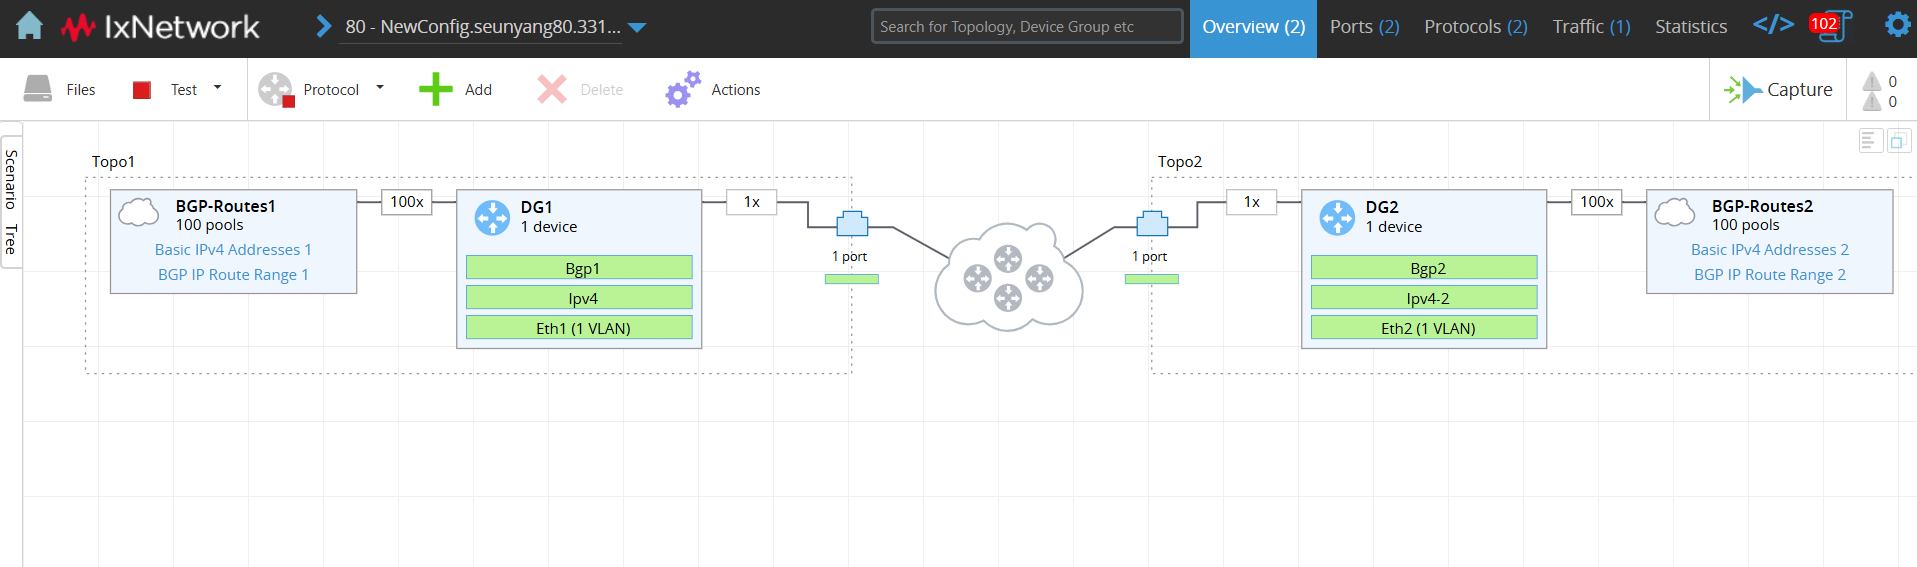

# Close the session

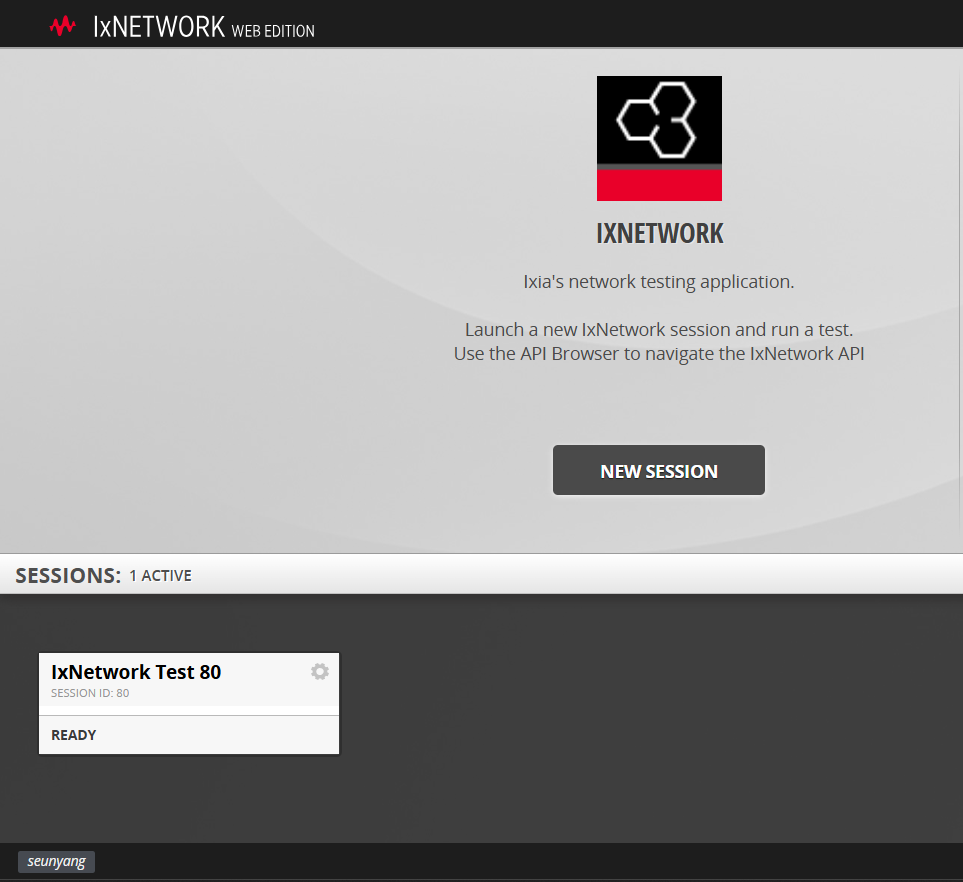

In [32]:
session.Session.remove()

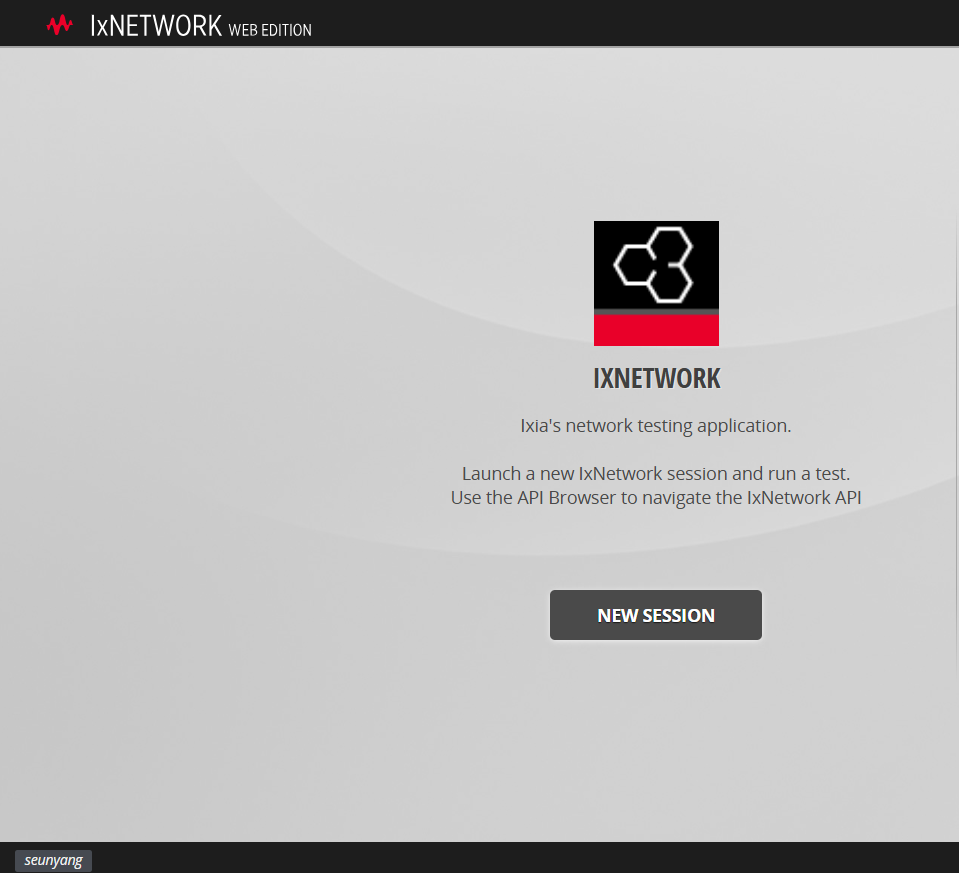